In [11]:
import numpy as np
import plotly.graph_objects as go
import math
import plotly.io as pio
pio.renderers.default = "png"

# Exercice 5.12 : Racetrack

In [12]:
def constructTrack(xMax, yMax):
    track = np.ones((yMax, xMax))
    starts = np.zeros(yMax)
    ends = xMax * np.ones(yMax)
    for y in range(yMax - 1, -1, -1):
        startMax = 2 * xMax // 3 if y == yMax - 1 else min(starts[y + 1] + 3, ends[y + 1])
        startMin = 0 if y == yMax - 1 else max(0, starts[y + 1] - 3)
        start = np.random.randint(startMin, startMax)
        endMinPrev = 1 if y == yMax - 1 else max(starts[y + 1] + 1, ends[y + 1])
        endMin = max(endMinPrev, start + 1)
        endMax = xMax if y == yMax - 1 else ends[y + 1] + 3
        end = np.random.randint(endMin, endMax + 1)
        track[y, :start] = 0
        track[y, end:] = 0
        starts[y] = start
        ends[y] = end

    track[-1, :] *= 2
    track[:, -1] *= 3
    return track

In [13]:
def plotTrack(track):

    fig = go.Figure(
        go.Heatmap(
            z=track,
            colorscale = [
                [0.00, "#FFFFFF"],  # hors piste
                [0.33, "#FFFFFF"],

                [0.33, "#404040"],  # piste
                [0.66, "#404040"],

                [0.66, "#CF4D4D"],  # départ
                [0.99, "#CF4D4D"],

                [1.00, "#2BA367"],  # arrivée
            ],
            showscale=False,
            xgap=1,
            ygap=1,
            hoverongaps=False,
        )
    )

    fig.update_layout(plot_bgcolor="white")

    fig.update_yaxes(scaleanchor="x",autorange="reversed")

    return fig


In [14]:
def encodeTRState(x, y, vx, vy, trackShape):
    return vx + 6 * (-vy) + 36 * (x + trackShape[1] * y)

def decodeTRState(s, trackShape):
    v = s % 36
    p = s // 36
    vx = v % 6
    vy = v // 6
    x = p % trackShape[1]
    y = p // trackShape[1]
    return (x, y, vx, -vy)

def encodeTRAction(ax, ay):
    return (ax + 1) + 3 * (ay + 1)

def decodeTRAction(a):
    ax = a % 3
    ay = a // 3
    return (ax - 1, ay - 1)

In [129]:
def decodeTRtrajectory(trackShape, trajectory):
    traj = []
    for t in range(len(trajectory)):
        # print(f"In state {decodeTRState(trajectory[t, 0], trackShape)}, do action {decodeTRAction(trajectory[t, 1])} and get reward {trajectory[t, 2]}")
        state = decodeTRState(trajectory[t, 0], trackShape)
        traj.append((state[0], state[1]))
    lastState = decodeTRState(trajectory[-1, 0], trackShape)
    lastAction = decodeTRAction(trajectory[-1, 1])
    crossedLineTraj = (lastState[0] + lastState[2] + lastAction[0], lastState[1] + lastState[3] + lastAction[1])
    traj.append(crossedLineTraj)

    return traj, len(trajectory)

In [16]:
def plotTrajectory(track, trajectory, title):
    fig = plotTrack(track)

    x = []
    y = []
    for step in trajectory:
        x += [step[0]]
        y += [step[1]]

    fig.add_trace(go.Scatter(x=x, y=y, mode="lines+markers", marker=dict(size=10, symbol="arrow", angleref="previous")))
    fig.update_layout(title=title)

    fig.show()

In [17]:
# Define a function that returns all cells visited when starting at position (x, y) and travelling with speed (vx, vy)
def rayTrace(x, y, vx, vy):
    if vx == 0:
        return [(x, yinter) for yinter in range(y, y + vy - 1, -1)]

    slope = vy / vx
    visitedCells = set({(x, y)})
    cells = [(x, y)]
    yStart = y + 0.5
    xStart = x + 0.5
    for xinter in range(x + 1, x + vx + 1):
        yinter = yStart + slope * (xinter - xStart)
        if yinter != math.floor(yinter):
            ycell = math.floor(yinter)
            if (xinter - 1, ycell) not in visitedCells:
                visitedCells.add((xinter - 1, ycell))
                cells.append((xinter - 1, ycell))
            if (xinter, ycell) not in visitedCells:
                visitedCells.add((xinter, ycell))
                cells.append((xinter, ycell))
        
        yinter = yStart + slope * (xinter + 0.5 - xStart)
        if yinter == math.floor(yinter):
            ycell = math.floor(yinter)
            if (xinter, ycell) not in visitedCells:
                visitedCells.add((xinter, ycell))
                cells.append((xinter, ycell))
            if (xinter, ycell - 1) not in visitedCells:
                visitedCells.add((xinter, ycell - 1))
                cells.append((xinter, ycell - 1))
        else:
            ycell = math.floor(yinter)
            if (xinter, ycell) not in visitedCells:
                visitedCells.add((xinter, ycell))
                cells.append((xinter, ycell))

    #TODO: do the same thing but while iterating over the ys (if the ascent is too steep, the xs aren't enough to capture all visited cells)

    return cells

# Define a function that returns the truth values of intersecting track bounderies and of crossing the finishing line when in x, y and travelling at speed vx, vy
def intersectsBoundary(track, state):
    finishx = track.shape[1] - 1
    finishy = np.where(track[:, -1] == 3)[0][-1]
    x, y, vx, vy = state
    visitedCells = rayTrace(x, y, vx, vy)
    for cell in visitedCells:
        xnext, ynext = cell
        if xnext <= finishx - 1:
            if ynext < 0:
                return True, False
            if track[ynext, xnext] == 0:
                return True, False
        if xnext == finishx:
            if ynext > finishy or ynext < 0:
                return True, False
            
    if xnext >= finishx:
        return False, True
    return False, False       

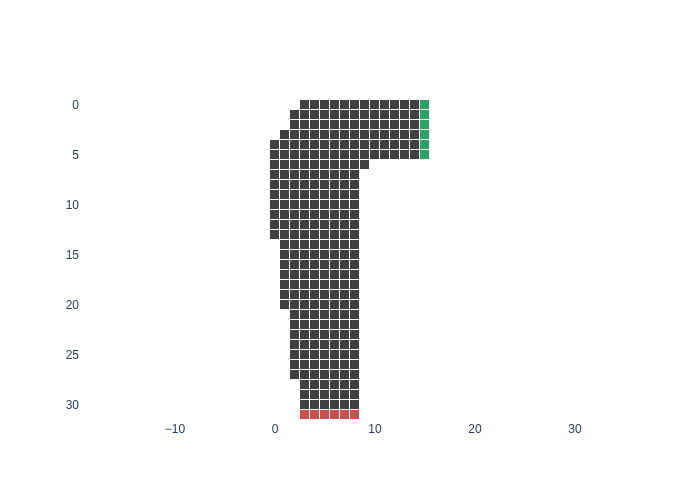

In [18]:
track1 = np.ones((32, 16))
track1[:, -1] *= 3
track1[-1, :] *= 2
track1[0, :3] *= 0
track1[1:3, :2] *= 0
track1[3, 0] = 0
track1[6, 10:] *= 0
track1[7:, 9:] *= 0
track1[14:, 0] *= 0
track1[21:, 1] *= 0
track1[28:, 2] *= 0
plotTrack(track1)

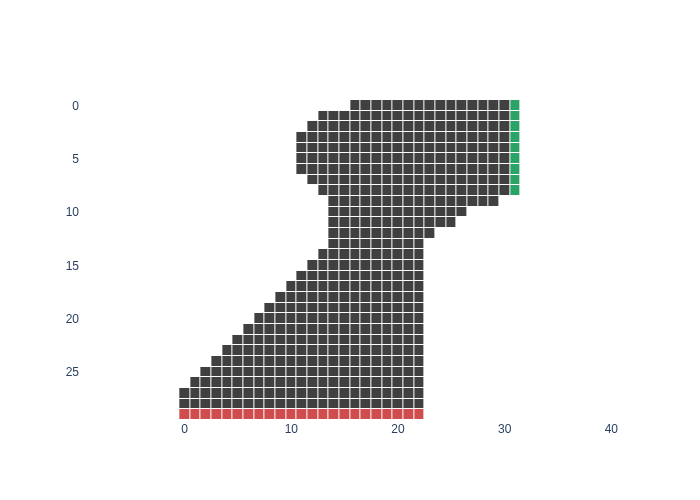

In [19]:
track2 = np.ones((30, 32))
track2[:, -1] *= 3
track2[-1, :-1] *= 2
track2[0, :16] *= 0
track2[1, :13] *= 0
track2[2, :12] *= 0
track2[3:17, :11] *= 0
track2[7:16, :12] *= 0
track2[8:15, :13] *= 0
track2[9:14, :14] *= 0
for l in range(11):
    track2[16+l, :11-l] *= 0
track2[9:, -2:] *= 0
track2[10:, -5:] *= 0
track2[11:, -6:] *= 0
track2[12:, -8:] *= 0
track2[13:, -9:] *= 0
plotTrack(track2)


## Monte Carlo model

In [20]:
def buildMCTRModel(track):
    nStates = 36 * track.shape[0] * track.shape[1]
    nActions = 9
    actionMapping = []
    for s in range(nStates):
        x, y, vx, vy = decodeTRState(s, track.shape)

        # if off track or on finish line, there is no action to take
        if track[y, x] == 0 or track[y, x] == 3:
            actionMapping.append([])
            continue

        # states where both velocities are null are not allowed (except at starting line)
        if y < track.shape[0] - 1 and vx == 0 and vy == 0:
            actionMapping.append([])
            continue
        
        else:
            axMin = max(-1, -vx)
            ayMin = max(-1, -(vy + 5))
            axMax = min(1, 5 - vx)
            ayMax = min(1, -vy)
            # only consider actions that do not get the vehicule to stand still or to get out of track
            actionMapping.append([encodeTRAction(ax, ay) for ax in range(axMin, axMax + 1) for ay in range(ayMin, ayMax + 1) 
                                        if not ((vx + ax == 0 and vy + ay == 0) or intersectsBoundary(track, (x, y, vx + ax, vy + ay))[0])])

    # Since it is strictly a right turn, discard all states that can not be reached from starting line while turning right
    firstSLx = np.where(track[-1, :] == 2)[0][0]

    for s in range(nStates):
        x, y, vx, vy = decodeTRState(s, track.shape)

        if x < firstSLx:
            actionMapping[s] = []


    # Discard all actions that moves the agent to a "doomed" state (i.e a state that any action makes the agent crash or transition to another such a doomed state)
    stable = False
    lens = [len(mapping) for mapping in actionMapping]
    while not stable:
        oldLens = lens

        for s in range(nStates):
            if len(actionMapping[s]) == 0:
                continue
            
            x, y, vx, vy = decodeTRState(s, track.shape)
            bannedActions = []

            for action in actionMapping[s]:
                ax, ay = decodeTRAction(action)
                # if agent does not cross finish line after applying the action
                if not intersectsBoundary(track, (x, y, vx + ax, vy + ay))[1]:
                    # if agent does not end up in an already deemed hopeless state
                    if len(actionMapping[encodeTRState(x + vx + ax, y + vy + ay, vx + ax, vy + ay, track.shape)]) == 0:
                        # then bann the action
                        bannedActions.append(action)
            for bannedAction in bannedActions:
                actionMapping[s].remove(bannedAction)

        lens = [len(mapping) for mapping in actionMapping]
        stable = lens == oldLens
        # repeat as long as actions get banned


    # Define a mask to store all "legal states" with their "legal actions"
    legalActions = np.zeros((nStates, 9), dtype=bool)
    for state, action in enumerate(actionMapping):
        legalActions[state, action] = True
    
    states = np.where(np.sum(legalActions, axis=1) >= 1)[0]
    legalStates = {state: i for i, state in enumerate(states)}


    return nStates, nActions, legalActions, actionMapping, legalStates, set(states)

In [21]:
# Sample a track race trajectory
# In case of allowing all actions (i.e allowing crashes), put a max length trajectory else the driver may never find the exit)
def sampleTRTrajectory(track, policy, legalStates, legalStatesSet, startingState=None, startingAction=None, noise=False, maxIter=10000):
    randomizedPolicy = len(policy.shape) == 2
    trackShape = track.shape
    if startingState is None:
        startingXcoordinate = np.random.choice(np.where(track[-1] == 2)[0])
        startingState = encodeTRState(startingXcoordinate, trackShape[0] - 1, 0, 0, trackShape)
        if randomizedPolicy:
            startingAction = np.random.choice(np.arange(9), p=policy[legalStates[startingState], :])
        else:
            startingAction = policy[legalStates[startingState]]

    stateTrajectory = []
    actionTrajectory = []
    rewardTrajectory = []

    currentState = startingState
    currentDecodedState = decodeTRState(currentState, trackShape)
    currentAction = startingAction
    currentDecodedAction = decodeTRAction(currentAction)
    crossedFinishLine = False
    outOfTrack = False

    iter = 0

    while not crossedFinishLine and iter < maxIter:
        iter += 1

        stateTrajectory += [currentState]
        actionTrajectory += [currentAction]
        rewardTrajectory += [-1]

        backToStart = np.random.choice([0, 1], p=[0.9, 0.1]) * noise
        
        if backToStart:
            currentDecodedState = (np.random.choice(np.where(track[-1] == 2)[0]), trackShape[0] - 1, 0, 0)
            currentState = encodeTRState(*currentDecodedState, trackShape)
            if randomizedPolicy:
                currentAction = np.random.choice(np.arange(9), p=policy[legalStates[currentState], :])
            else:
                currentAction = policy[legalStates[currentState]]
            currentDecodedAction = decodeTRAction(currentAction)

        else:
            nextVx = currentDecodedState[2] + currentDecodedAction[0]
            nextVy = currentDecodedState[3] + currentDecodedAction[1]

            intermediaryState = (currentDecodedState[0], currentDecodedState[1], nextVx, nextVy)
            outOfTrack, crossedFinishLine = intersectsBoundary(track, intermediaryState)

            if not (outOfTrack or crossedFinishLine):
                currentDecodedState = (currentDecodedState[0] + nextVx, currentDecodedState[1] + nextVy, nextVx, nextVy)
                currentState = encodeTRState(*currentDecodedState, trackShape)
                if not currentState in legalStatesSet:
                    outOfTrack = True


            if outOfTrack:
                currentDecodedState = (np.random.choice(np.where(track[-1] == 2)[0]), trackShape[0] - 1, 0, 0)
                currentState = encodeTRState(*currentDecodedState, trackShape)

            if not crossedFinishLine:
                if randomizedPolicy:
                    currentAction = np.random.choice(np.arange(9), p=policy[legalStates[currentState], :])
                else:
                    currentAction = policy[legalStates[currentState]]
                currentDecodedAction = decodeTRAction(currentAction)
        
    trajectory = np.empty((len(stateTrajectory), 3), dtype=int)
    trajectory[:, 0] = stateTrajectory
    trajectory[:, 1] = actionTrajectory
    trajectory[:, 2] = rewardTrajectory

    return trajectory

In [22]:
ySL = track1.shape[0] - 1
startingStatesTrack1 = []
for xSL in range(track1.shape[1]):
    if track1[ySL, xSL] == 2:
        startingState = encodeTRState(xSL, ySL, 0, 0, track1.shape)
        startingStatesTrack1.append(startingState)

In [23]:
ySL = track2.shape[0] - 1
startingStatesTrack2 = []
for xSL in range(track2.shape[1]):
    if track2[ySL, xSL] == 2:
        startingState = encodeTRState(xSL, ySL, 0, 0, track2.shape)
        startingStatesTrack2.append(startingState)

In [24]:
modelTrack1 = buildMCTRModel(track1)
nStatesTrack1, nActionsTR, legalActionsTrack1, actionMappingTrack1, legalStatesTrack1, legalStatesSetTrack1 = modelTrack1

In [25]:
modelTrack2 = buildMCTRModel(track2)
nStatesTrack2, nActionsTR, legalActionsTrack2, actionMappingTrack2, legalStatesTrack2, legalStatesSetTrack2 = modelTrack2

In [26]:
policyInitTrack1 = np.empty(nStatesTrack1, dtype=int)
for s in range(nStatesTrack1):
    if len(actionMappingTrack1[s]):
        policyInitTrack1[s] = np.random.choice(actionMappingTrack1[s])

policyInitTrack1 = policyInitTrack1[list(legalStatesTrack1.keys())]

In [27]:
policyInitTrack2 = np.empty(nStatesTrack2, dtype=int)
for s in range(nStatesTrack2):
    if len(actionMappingTrack2[s]):
        policyInitTrack2[s] = np.random.choice(actionMappingTrack2[s])

policyInitTrack2 = policyInitTrack2[list(legalStatesTrack2.keys())]

### First Visit MCC and Exploring Starts

In [28]:
def monteCarloControlTR(track, model, gamma, maxIter, qInit, policyInit, noise=False, maxTrajLength=1000, EV=False):
    nStates, nActions, legalActions, actionMapping, legalStates, legalStatesSet = model
    nLegalStates = len(legalStates)
    legalStateKeys = list(legalStates.keys())
   
    Q = qInit.copy() # qInit should have the same number of rows as legalStates length
    policy = policyInit.copy() # has the same number of rows as legalStates length
    nVisits = np.zeros((nLegalStates, nActions))
    iter = 0
    # trajLengths = []
 
    while iter < maxIter:
        # if iter % (maxIter // 5) == 0:
        #     print(f"Iteration {iter}")
 
        startingState = np.random.choice(legalStateKeys)
        startingAction = np.random.choice(actionMapping[startingState])
 
        trajectory = sampleTRTrajectory(track, policy, legalStates, legalStatesSet, startingState=startingState, startingAction=startingAction, noise=noise, maxIter=maxTrajLength)
        gain = 0.0
        T = len(trajectory)
 
        # if (iter + 1) % 10 == 0:
        #     print(f"Current trajectory average length {np.mean(trajLengths)}")
        #     trajLengths = []
 
        # trajLengths.append(T)
        
        if not EV:
            gains = np.zeros(T)
        for t in range(T - 1, -1, -1):
            gain = gamma * gain + trajectory[t, 2]
            if EV:
                currentState = legalStates[trajectory[t, 0]]
                currentAction = trajectory[t, 1]
                nVisits[currentState, currentAction] += 1
                Q[currentState, currentAction] += (gain - Q[currentState, currentAction]) / nVisits[currentState, currentAction]
                policy[currentState] = np.argmax(Q[currentState, :])

            else:
                gains[t] = gain
        

        if not EV:
            visited = set()
            for t in range(T):
                currentState = legalStates[trajectory[t, 0]]
                currentAction = trajectory[t, 1]
                if (currentState, currentAction) in visited:
                    continue
                visited.add((currentState, currentAction))
    
                nVisits[currentState, currentAction] += 1
                Q[currentState, currentAction] += (gains[t] - Q[currentState, currentAction]) / nVisits[currentState, currentAction]
                policy[currentState] = np.argmax(Q[currentState, :])
 
        iter += 1
 
    return Q, policy


#### Track 1

In [138]:
qInitMCCESTrack1 = np.zeros((len(legalStatesTrack1), nActionsTR))
for id, state in enumerate(legalStatesTrack1):
    for action in range(9):
        if not legalActionsTrack1[state, action]:
            qInitMCCESTrack1[id, action] = -np.inf
            
maxTrajLength = 1000
nItersTrack1FVMCCES = 100000
qStarMCCESTrack1, policyStarMCCESTrack1 = monteCarloControlTR(track1, modelTrack1, 1, nItersTrack1FVMCCES, qInitMCCESTrack1, policyInitTrack1, noise=True, maxTrajLength=maxTrajLength, EV=False)

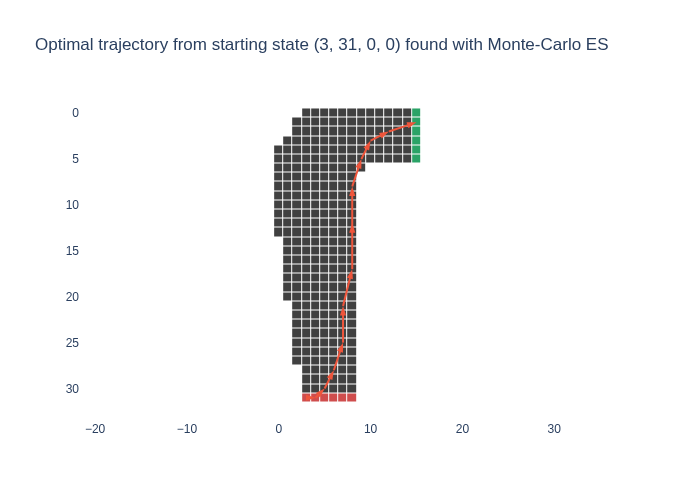

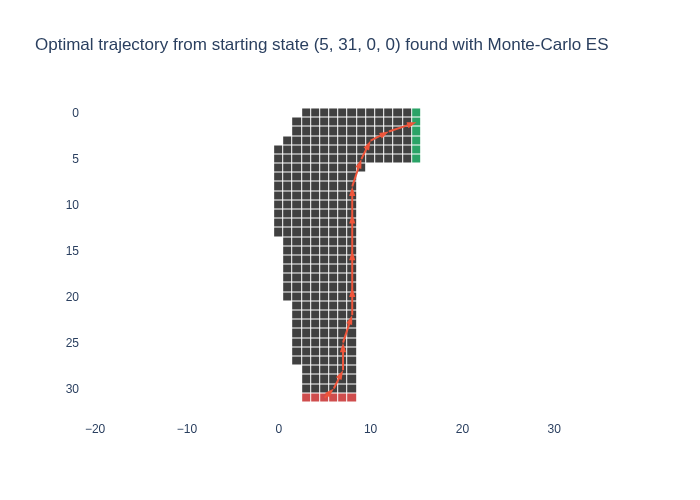

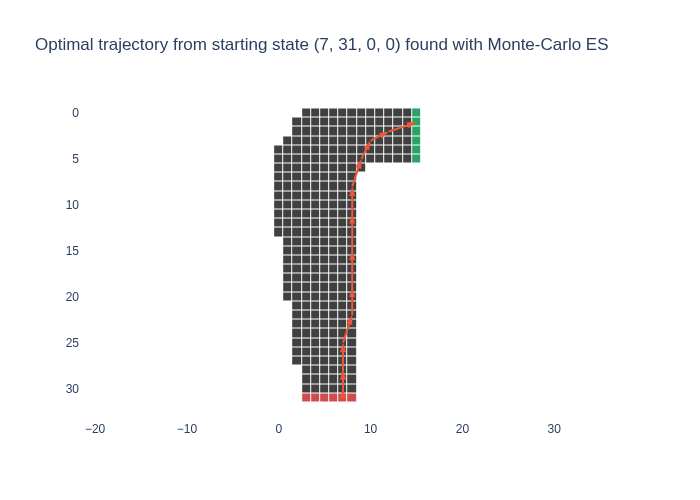

In [139]:
trajLengthsMCCESTrack1 = []
i = 0
for startingState in startingStatesTrack1:
    startingAction = policyStarMCCESTrack1[legalStatesTrack1[startingState]]
    decodedTraj, trajLength = decodeTRtrajectory(track1.shape, sampleTRTrajectory(track1, policyStarMCCESTrack1, legalStatesTrack1, legalStatesSetTrack1, startingState=startingState, startingAction=startingAction, noise=False, maxIter=1000))
    if i % 2 == 0:
        plotTrajectory(track1, decodedTraj, 
                    title=f"Optimal trajectory from starting state {decodeTRState(startingState, track1.shape)} found with Monte-Carlo ES")
    trajLengthsMCCESTrack1.append(trajLength)
    i += 1

#### Track 2

In [136]:
qInitMCCESTrack2 = np.zeros((len(legalStatesTrack2), nActionsTR))
for id, state in enumerate(legalStatesTrack2):
    for action in range(9):
        if not legalActionsTrack2[state, action]:
            qInitMCCESTrack2[id, action] = -np.inf
            
maxTrajLength = 1000
nItersTrack2FVMCCES = 100000
qStarMCCESTrack2, policyStarMCCESTrack2 = monteCarloControlTR(track2, modelTrack2, 1, nItersTrack2FVMCCES, qInitMCCESTrack2, policyInitTrack2, noise=True, maxTrajLength=maxTrajLength, EV=False)

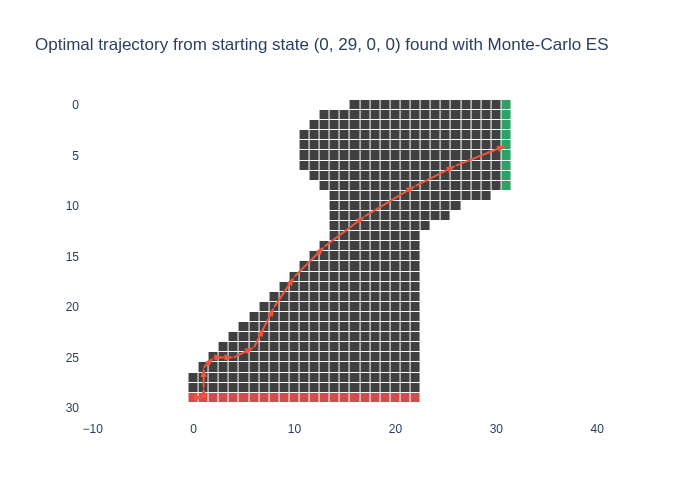

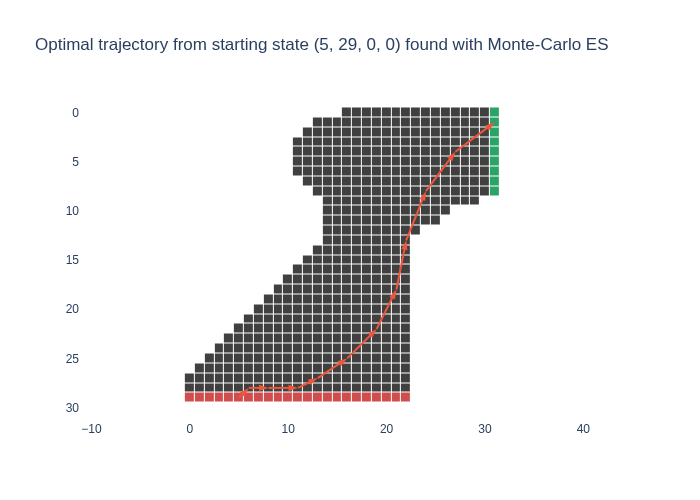

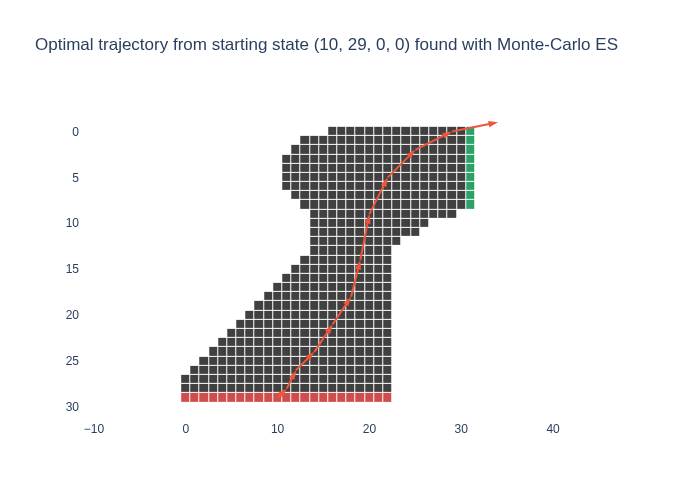

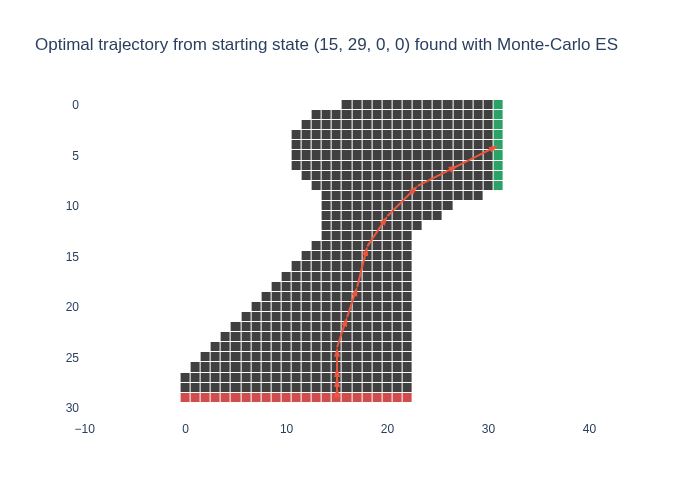

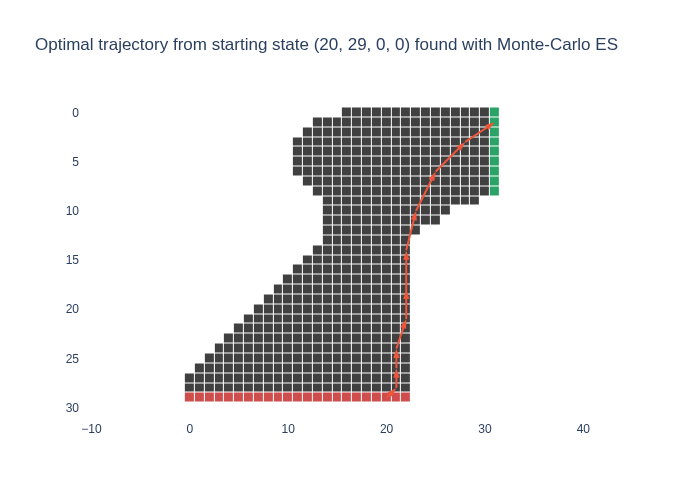

In [140]:
trajLengthsMCCESTrack2 = []
i = 0
for startingState in startingStatesTrack2:
    startingAction = policyStarMCCESTrack2[legalStatesTrack2[startingState]]
    decodedTraj, trajLength = decodeTRtrajectory(track2.shape, sampleTRTrajectory(track2, policyStarMCCESTrack2, legalStatesTrack2, legalStatesSetTrack2, startingState=startingState, startingAction=startingAction, noise=False, maxIter=2000))
    if i % 5 == 0:
        plotTrajectory(track2, decodedTraj, 
                    title=f"Optimal trajectory from starting state {decodeTRState(startingState, track2.shape)} found with Monte-Carlo ES")
    trajLengthsMCCESTrack2.append(trajLength)
    i += 1

### Off-Policy Every Visit MCC

In [37]:
def offPolicyEVMCC(track, model, gamma, maxIter, policyInit, qInit, epsilon=0.001, noise=False, maxTrajLength=1000):
    nStates, nActions, legalActions, actionMapping, legalStates, legalStatesSet = model
    nLegalStates = len(legalStates)
    legalStateKeys = list(legalStates.keys())
    nLegalActions = legalActions.sum(axis=1)[:, None]
   
    Q = qInit.copy() # qInit should have the same number of rows as legalStates length
    targetPolicy = policyInit.copy() # has the same number of rows as legalStates length
    ratios = np.zeros((nLegalStates, nActions))
    iter = 0
    # trajLengths = []
 
    iter = 0
 
    behaviourPolicy = legalActions[legalStateKeys].astype(float) / nLegalActions[legalStateKeys]
    updatedPolicyStates = []
    updatedPolicyIds = []
 
    while iter < maxIter:
        # if iter % (maxIter // 5) == 0:
        #     print(f"Iteration {iter}")
 
        if updatedPolicyIds:
            behaviourPolicy[updatedPolicyIds, :] = epsilon * legalActions[updatedPolicyStates] / nLegalActions[updatedPolicyStates]
            behaviourPolicy[updatedPolicyIds, targetPolicy[updatedPolicyIds]] += 1 - epsilon 
 
        trajectory = sampleTRTrajectory(track, behaviourPolicy, legalStates, legalStatesSet, noise=noise, maxIter=maxTrajLength)
 
        gain = 0.0
        weight = 1
        t = len(trajectory) - 1
 
        # if (iter + 1) % (maxIter // 100) == 0:
        #     print(f"Current trajectory average length {np.mean(trajLengths)}")
        #     trajLengths = []
 
        # trajLengths.append(t + 1)
           
        while t >= 0:
            gain = gamma * gain + trajectory[t, 2]
            currentState = legalStates[trajectory[t, 0]]
            currentAction = trajectory[t, 1]
 
            ratios[currentState, currentAction] += weight
            Q[currentState, currentAction] += weight * (gain - Q[currentState, currentAction]) / ratios[currentState, currentAction]

            oldPolicy = targetPolicy[currentState]
            targetPolicy[currentState] = np.argmax(Q[currentState, :])
            
            if oldPolicy != targetPolicy[currentState]:
                updatedPolicyStates.append(trajectory[t, 0])
                updatedPolicyIds.append(currentState)
                
            if targetPolicy[currentState] != currentAction:
                t = -1
            else:
                weight *= 1 / behaviourPolicy[currentState, currentAction]
                t -= 1
 
        iter += 1
   
    return Q, targetPolicy

#### Track 1

In [62]:
qInitOPMCCTrack1 = np.empty((len(legalStatesTrack1), nActionsTR))
for state, id in legalStatesTrack1.items():
    for action in range(9):
        if not legalActionsTrack1[state, action]:
            qInitOPMCCTrack1[id, action] = -np.inf
nItersOPMCCTrack1 = 100000
maxTrajLength = 1000
qStarOPMCCTrack1, policyStarOPMCCTrack1 = offPolicyEVMCC(track1, modelTrack1, 1, nItersOPMCCTrack1, policyInitTrack1, qInitOPMCCTrack1, epsilon=0.01, maxTrajLength=maxTrajLength, noise=True)

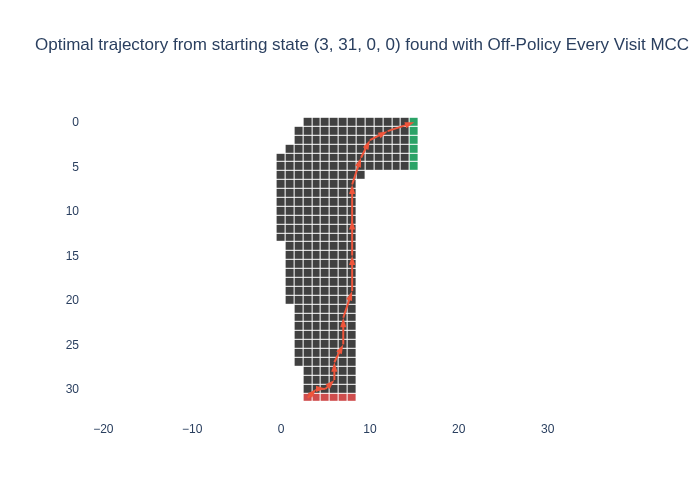

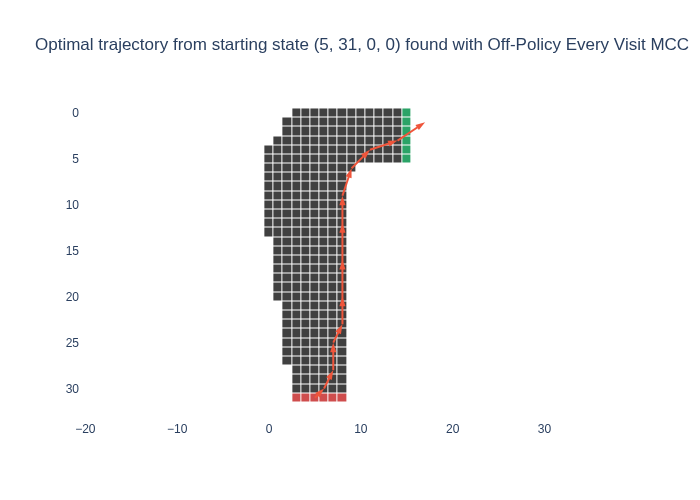

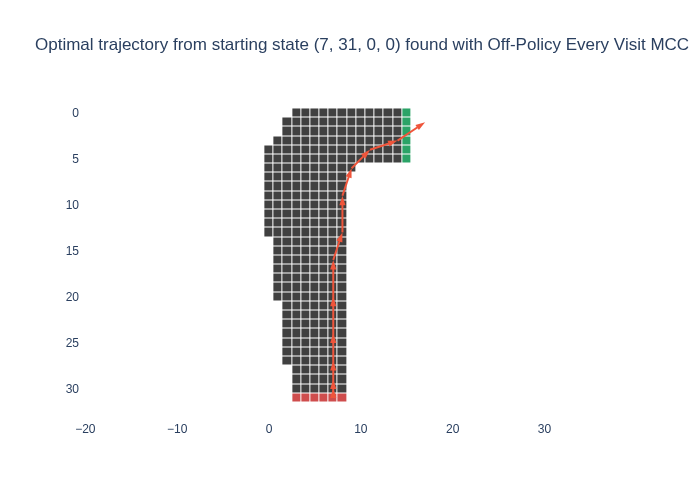

In [141]:
trajLengthsOPMCCTrack1 = []
i = 0
for startingState in startingStatesTrack1:
    startingAction = policyStarOPMCCTrack1[legalStatesTrack1[startingState]]
    decodedTraj, trajLength = decodeTRtrajectory(track1.shape, sampleTRTrajectory(track1, policyStarOPMCCTrack1, legalStatesTrack1, legalStatesSetTrack1, startingState=startingState, startingAction=startingAction, noise=False, maxIter=1000))
    if i % 2 == 0:
        plotTrajectory(track1, decodedTraj, 
                    title=f"Optimal trajectory from starting state {decodeTRState(startingState, track1.shape)} found with Off-Policy Every Visit MCC")
    trajLengthsOPMCCTrack1.append(trajLength)
    i += 1

#### Track 2

In [64]:
qInitOPMCCTrack2 = np.empty((len(legalStatesTrack2), nActionsTR))
for state, id in legalStatesTrack2.items():
    for action in range(9):
        if not legalActionsTrack2[state, action]:
            qInitOPMCCTrack2[id, action] = -np.inf
nItersOPMCCTrack2 = 100000
maxTrajLength = 1000
qStarOPMCCTrack2, policyStarOPMCCTrack2 = offPolicyEVMCC(track2, modelTrack2, 1, nItersOPMCCTrack2, policyInitTrack2, qInitOPMCCTrack2, epsilon=0.01, maxTrajLength=maxTrajLength, noise=True)

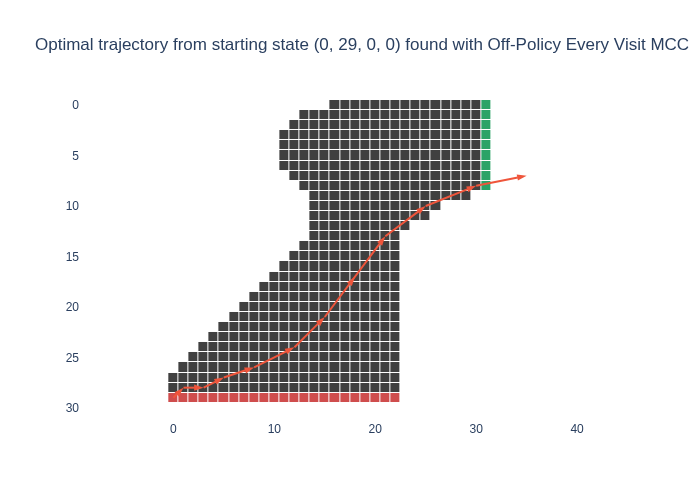

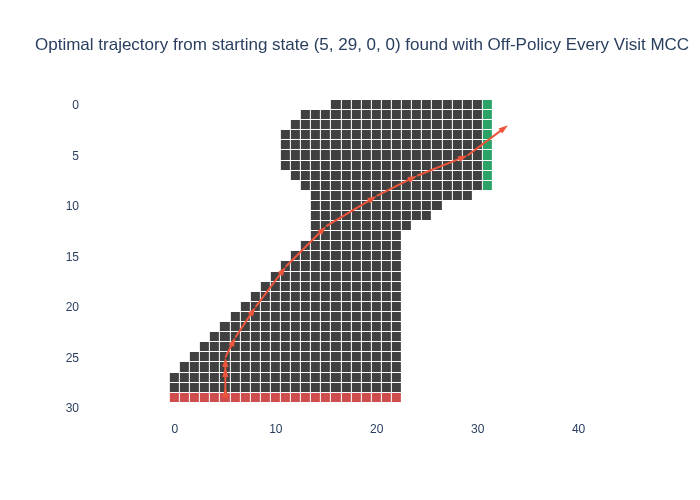

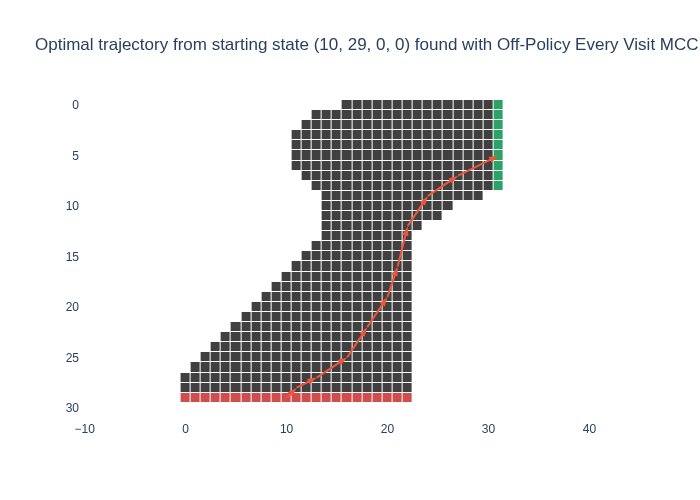

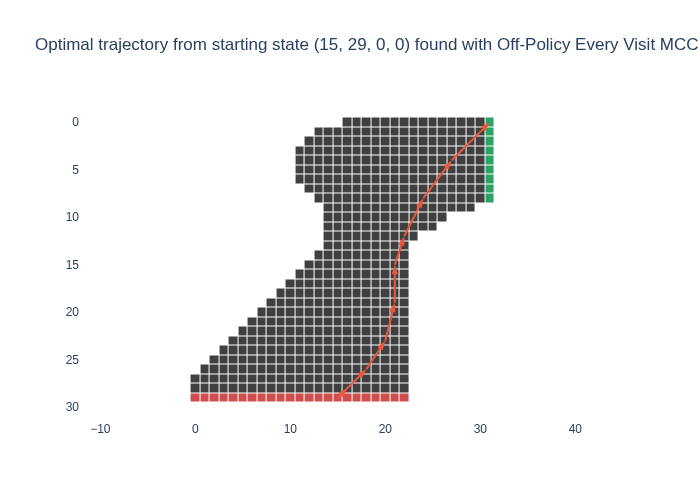

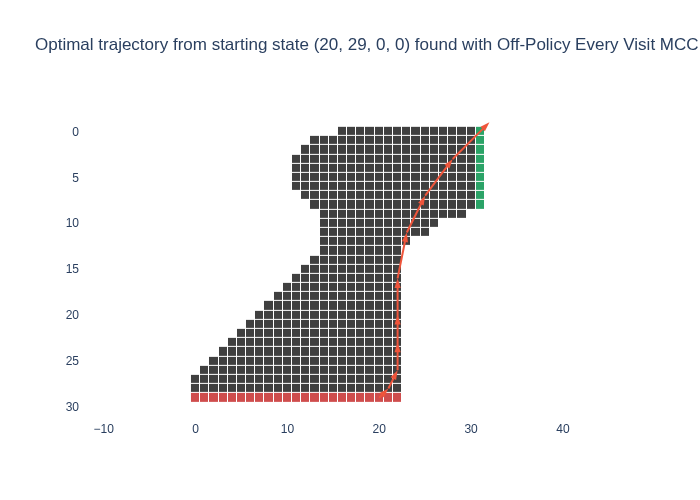

In [148]:
trajLengthsOPMCCTrack2 = []
i = 0
for startingState in startingStatesTrack2:
    startingAction = policyStarOPMCCTrack2[legalStatesTrack2[startingState]]
    decodedTraj, trajLength = decodeTRtrajectory(track2.shape, sampleTRTrajectory(track2, policyStarOPMCCTrack2, legalStatesTrack2, legalStatesSetTrack2, startingState=startingState, startingAction=startingAction, noise=False, maxIter=2000))
    if i % 5 == 0:
        plotTrajectory(track2, decodedTraj, 
                    title=f"Optimal trajectory from starting state {decodeTRState(startingState, track2.shape)} found with Off-Policy Every Visit MCC")
    trajLengthsOPMCCTrack2.append(trajLength)
    i += 1

## Value iteration

In [93]:
def buildMDPTRModel(track, noise=True):
    nStates, nActions, legalActions, actionMapping, legalStates, statesSet = buildMCTRModel(track)

    dynamics = np.zeros((len(legalStates), nActions, len(legalStates)))
    rewardMapping = np.zeros((len(legalStates), nActions))
    ySL = track.shape[0] - 1
    startingStates = []
    for xSL in range(track.shape[1]):
        if track[ySL, xSL] == 2:
            startingState = encodeTRState(xSL, ySL, 0, 0, track.shape)
            startingStates.append(legalStates[startingState])

    for s, id in legalStates.items():
        for a in actionMapping[s]:
            x, y, vx, vy = decodeTRState(s, track.shape)
            ax, ay = decodeTRAction(a)
            nextVx, nextVy = vx + ax, vy + ay
            offTrack, crossedFinishLine = intersectsBoundary(track, (x, y, nextVx, nextVy))
            if offTrack:
                dynamics[id, a, startingState] = 1 / len(startingStates)
                rewardMapping[id, a] = -1
            if not (offTrack or crossedFinishLine): 
                nextState = legalStates[encodeTRState(x + nextVx, y + nextVy, nextVx, nextVy, track.shape)]
                dynamics[id, a, nextState] = 0.9 * noise + 1 * (1 - noise)
                dynamics[id, a, startingStates] = 0.1 * noise / len(startingStates)
                rewardMapping[id, a] = -1
            if crossedFinishLine:
                rewardMapping[id, a] = 0
            
    return dynamics, rewardMapping

In [103]:
def valueIterTR(modelMDP, modelMCC, theta, gamma, vInit):
    # Initialization
    nStates, nActions, legalActions, actionMapping, legalStates, statesSet = modelMCC
    dynamics, rewardMapping = modelMDP
    nLegalStates = len(legalStates)

    V = vInit.copy()
    policy = np.empty(vInit.shape, dtype=int)
    iter = 0
    converged = False

    while not converged:
        # if iter % 50 == 0:
        #     print(f"iteration {iter}")
            
        delta = 0
        for s, id in legalStates.items():
            v = V[id]
            # Greedy action improv
            maxi = None
            for a in actionMapping[s]:
                qValAction = rewardMapping[id, a] + gamma * np.sum(dynamics[id, a, :] * V)
                if maxi is None or qValAction > maxi:
                    maxi = qValAction
                    argmax = a
 
            policy[id] = argmax
            V[id] = maxi
            delta = max(delta, abs(v - V[id]))
 
        converged = delta < theta      
 
        iter += 1

    print("Total number of iteration before convergence ", iter)
 
    return V, policy

In [97]:
# Model
modelMDPTrack1 = buildMDPTRModel(track1, noise=True)
modelMDPTrack2 = buildMDPTRModel(track2, noise=True)

### Track 1

In [ ]:
vInitMDPTRTrack1 = np.zeros(len(legalStatesTrack1))
epsilonMDPTRTrack1 = 1e-5
vStarMDPTRTrack1, policyStarMDPTRTrack1 = valueIterTR(modelMDPTrack1, modelTrack1, epsilonMDPTRTrack1, 1, vInitMDPTRTrack1)

Total number of iteration before convergence  30


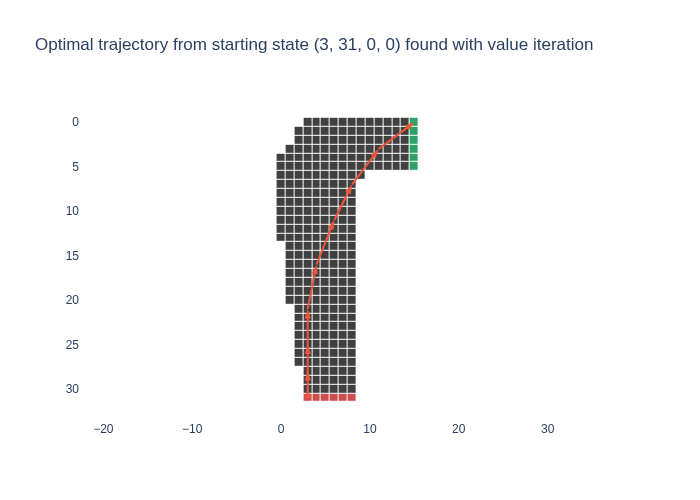

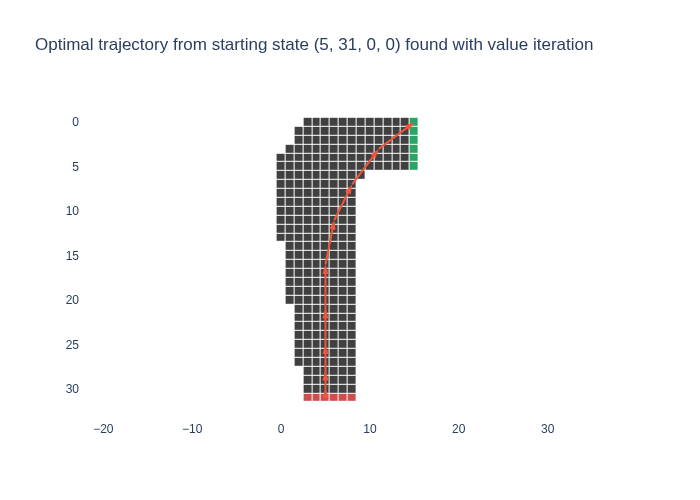

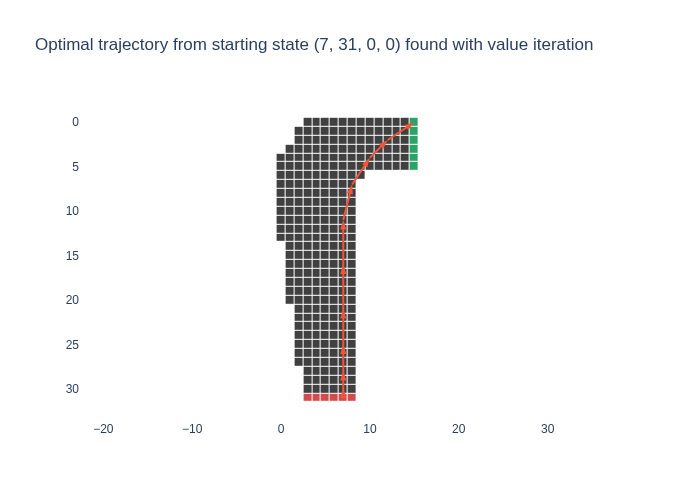

In [143]:
trajLengthsMDPTRTrack1 = []
i = 0
for startingState in startingStatesTrack1:
    startingAction = policyStarMDPTRTrack1[legalStatesTrack1[startingState]]
    decodedTraj, trajLength = decodeTRtrajectory(track1.shape, sampleTRTrajectory(track1, policyStarMDPTRTrack1, legalStatesTrack1, legalStatesSetTrack1, startingState=startingState, startingAction=startingAction, noise=False, maxIter=1000))
    if i % 2 == 0:
        plotTrajectory(track1, decodedTraj, 
                    title=f"Optimal trajectory from starting state {decodeTRState(startingState, track1.shape)} found with value iteration")
    trajLengthsMDPTRTrack1.append(trajLength)
    i += 1

### Track 2

In [122]:
vInitMDPTRTrack2 = np.zeros(len(legalStatesTrack2))
epsilonMDPTRTrack2 = 1e-5
vStarMDPTRTrack2, policyStarMDPTRTrack2 = valueIterTR(modelMDPTrack2, modelTrack2, epsilonMDPTRTrack2, 1, vInitMDPTRTrack2)

Total number of iteration before convergence  32


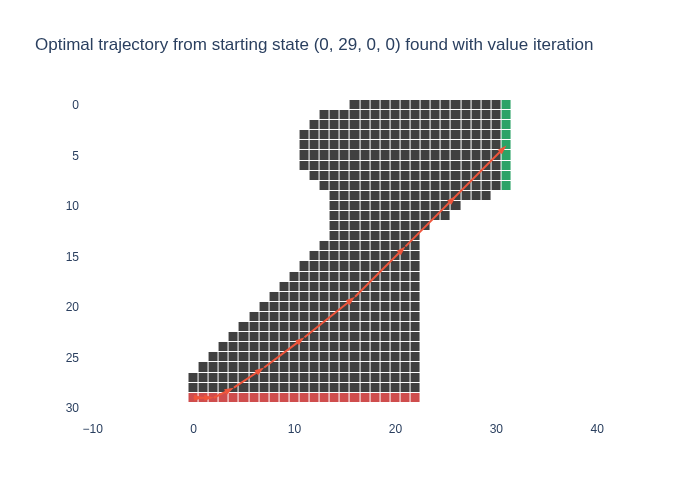

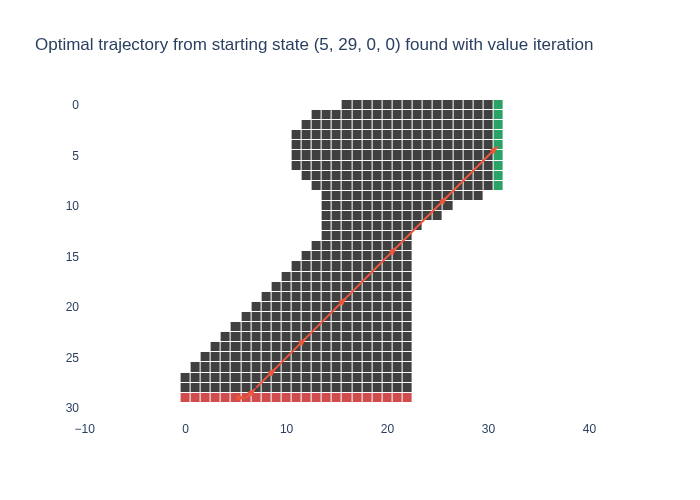

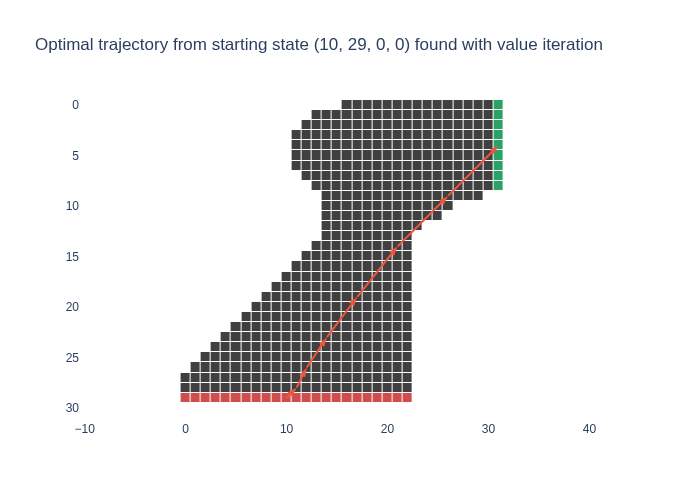

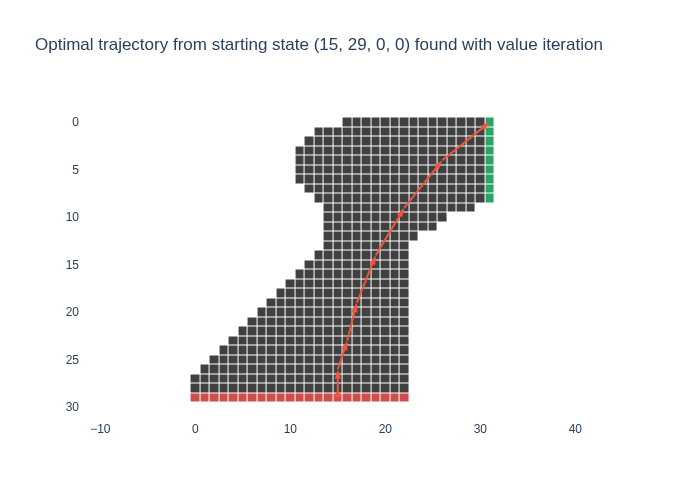

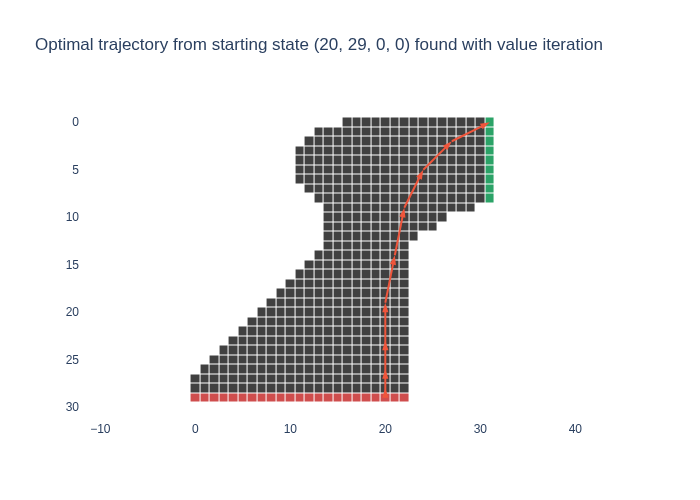

In [149]:
trajLengthsMDPTRTrack2 = []
i = 0
for startingState in startingStatesTrack2:
    startingAction = policyStarMDPTRTrack2[legalStatesTrack2[startingState]]
    decodedTraj, trajLength = decodeTRtrajectory(track2.shape, sampleTRTrajectory(track2, policyStarMDPTRTrack2, legalStatesTrack2, legalStatesSetTrack2, startingState=startingState, startingAction=startingAction, noise=False, maxIter=2000))
    if i % 5 == 0:
        plotTrajectory(track2, decodedTraj, 
                    title=f"Optimal trajectory from starting state {decodeTRState(startingState, track2.shape)} found with value iteration")
    trajLengthsMDPTRTrack2.append(trajLength)
    i += 1

## Comparison

In [151]:
def plotValuesTR(solutions, title):
    fig = go.Figure()
    for method, lengths in solutions.items():
        y = [l for l in lengths]
        fig.add_trace(go.Scatter(y=y, name=method))
    fig.update_layout(width=1200, title=title, xaxis_title="Starting states", yaxis_title="Estimate of v")
    fig.show()


### Track 1

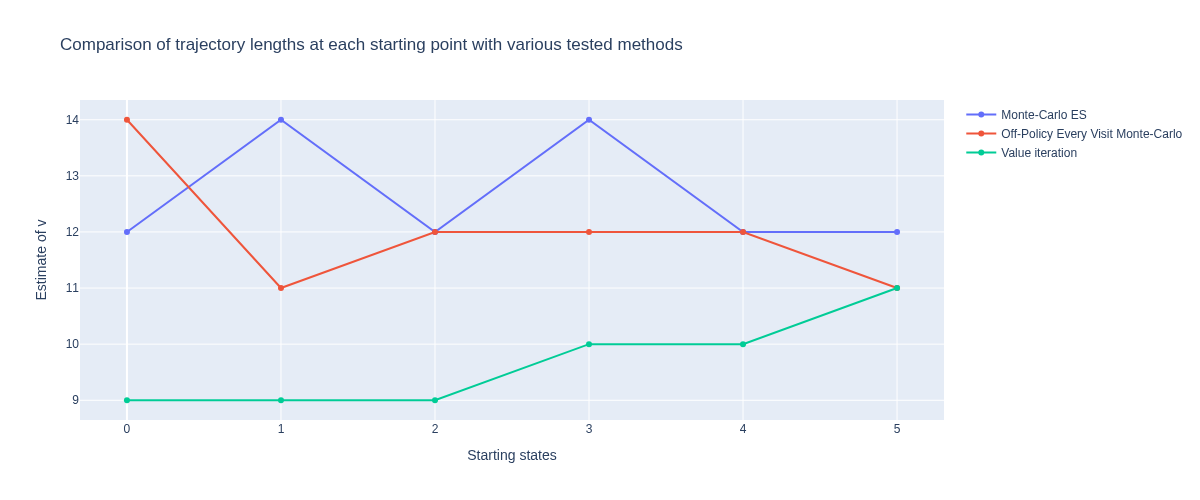

In [152]:
solutionsTrack1 = {"Monte-Carlo ES": trajLengthsMCCESTrack1, "Off-Policy Every Visit Monte-Carlo": trajLengthsOPMCCTrack1, "Value iteration": trajLengthsMDPTRTrack1}

plotValuesTR(solutionsTrack1, title="Comparison of trajectory lengths at each starting point with various tested methods")

### Track 2

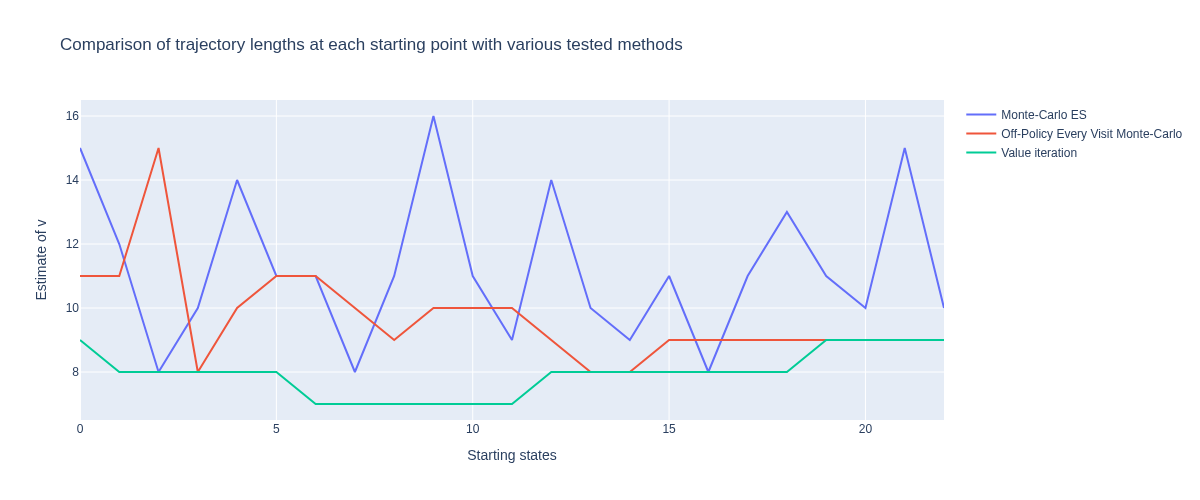

In [153]:
solutionsTrack2 = {"Monte-Carlo ES": trajLengthsMCCESTrack2, "Off-Policy Every Visit Monte-Carlo": trajLengthsOPMCCTrack2, "Value iteration": trajLengthsMDPTRTrack2}

plotValuesTR(solutionsTrack2, title="Comparison of trajectory lengths at each starting point with various tested methods")

# Exercice 5.14

By definition, the ordinary importance-sampling estimator of $q$ estimates the expectation $$\mathbb{E}_b[\rho_{t+1:T-1} G_t]$$
with $$\rho_{t+1:T-1} G_t = \rho_{t+1:T-1} R_{t+1} + \rho_{t+1:T-1} R_{t+2} + \cdots + \rho_{t+1:T-1} R_{T-1} + \rho_{t+1:T-1} R_{T}$$
Furthermore, we have that $$\rho_{t+1:T-1} R_{t+1} = \frac{\pi(A_{t+1}|S_{t+1})}{b(A_{t+1}|S_{t+1})} \cdots \frac{\pi(A_{T-1}|S_{T-1})}{b(A_{T-1}|S_{T-1})}R_{t+1}$$
Let us denote by $X_k = (S_k, A_k)$, $X'_k = (S_k, A_k, R_k)$, $f: (s, a) \mapsto \frac{\pi(a|s)}{b(a|s)}$ and $g: (s, a, r) \mapsto f(s, a)r$. We want to estimate the expectation $$\mathbb{E}_b[\rho_{t+1:T-1} R_{t+1}] = \mathbb{E}_b[g(X'_{t+1})f(X_{t+2}) \cdots f(X_{T-2}) f(X_{T-1})]$$
Noting that the random variables $(X'_{t+1}, (X_k)_{t+2\leq k \leq T-1})$ are independent from the random variable $X_{T-1}$, we derive the following expression by conditioning on $X_{T-1}$:
\begin{align}
\mathbb{E}_b[\rho_{t+1:T-1} R_{t+1}] &= \mathbb{E}_b[\mathbb{E}_b[g(X'_{t+1}) f(X_{t+2}) \cdots f(X_{T-2}) f(X_{T-1}) | X_{T-1}]] \\
                                        &= \mathbb{E}_b[\mathbb{E}_b[g(X'_{t+1}) f(X_{t+2}) \cdots f(X_{T-2})] f(X_{T-1}) | X_{T-1}] \\
                                        &= \mathbb{E}_b[g(X'_{t+1}) f(X_{t+2}) \cdots f(X_{T-2})] \underbrace{\mathbb{E}_b[f(X_{T-1}) | X_{T-1}]}_{=\mathbb{E}_b[f(X_{T-1})] = 1} \\
\end{align}
Following the same reasoning, we arrive at $\mathbb{E}_b[\rho_{t+1:T-1} R_{t+1}] = \mathbb{E}_b[g(X'_{t+1})] = \mathbb{E}_b[\frac{\pi(A_{t+1}|S_{t+1})}{b(A_{t+1}|S_{t+1})}R_{t+1}] = \mathbb{E}_b[\rho_{t+1:t+1} R_{t+1}]$

This reasoning is carried out to compute all the remaining terms of the original expectations, so that
$$\begin{cases}
\mathbb{E}_b[\rho_{t+1:T-1} R_{t+1}] = \mathbb{E}_b[\rho_{t+1:t+1} R_{t+1}] &\\
\mathbb{E}_b[\rho_{t+1:T-1} R_{t+k}] = \mathbb{E}_b[\rho_{t+1:t+k-1} R_{t+k}] & \text{for } 2 \leq k \leq T-t
\end{cases}$$

It follows that the expectation $$\mathbb{E}_b[\rho_{t+1:T-1} G_t] = \mathbb{E}_b[G'_t]$$ where $$G'_t= \rho_{t+1:t+1} R_{t+1} + \sum_{k=1}^{T-t-1}\gamma^k \rho_{t+1:t+k}R_{t+1+k}$$
so that the ordinary-sampling estimator for the action-value function can be written as 
$$Q(s, a) = \frac{\sum_{t\in\mathcal{T}(s,a)} G'_t}{|\mathcal{T}(s,a)|}